In [1]:
from google.colab import files
upload = files.upload()

Saving Walmart DataSet.csv to Walmart DataSet.csv


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("/content/Walmart DataSet.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.isna().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [10]:
df.Date = pd.to_datetime(df.Date, format="%d-%m-%Y")

In [13]:
df.dtypes

,0
Store,int64
Date,datetime64[ns]
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [23]:
result = df[['Weekly_Sales', 'Unemployment']].corr().iloc[0,1]
if result < 0:
  print("Higher the unemployment, lower the weakly sales")
else:
  print("Lower the unemploymnet, higher the weakly sales")

Higher the unemployment, lower the weakly sales


In [29]:
store_corr = {}
store_correlation = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['Unemployment']))
store_correlation.sort_values()
for key, value in store_correlation.items():
  store_corr[key] = value
print(store_corr)

{1: -0.0979553947295795, 2: 0.06632485967770846, 3: -0.2304130134863526, 4: -0.3370151956445587, 5: -0.20704271031605842, 6: 0.044250821015624046, 7: -0.16538168270129636, 8: -0.05257964619712677, 9: -0.1915343637022839, 10: 0.13190762207746096, 11: -0.020338971133082306, 12: -0.009286099902746538, 13: -0.1716328688963503, 14: 0.2107864829459358, 15: 0.0789053686051426, 16: -0.07086358405192238, 17: -0.26359968183073906, 18: 0.13917900226669452, 19: 0.10146392090273439, 20: -0.09534134450284637, 21: 0.21836733305703376, 22: 0.039042867355347455, 23: -0.07716899559088829, 24: -0.012260801238922888, 25: -0.004957651760361549, 26: -0.06689910263473302, 27: -0.0142750519412613, 28: 0.1366706817794531, 29: 0.08468168200648409, 30: 0.20186223641523895, 31: -0.06473780907548937, 32: -0.09945467124759011, 33: 0.10117473193757327, 34: 0.01701025065278913, 35: 0.4838654198192479, 36: 0.8337336178415085, 37: -0.22128669565468617, 38: -0.7852902748572028, 39: -0.38468135708616064, 40: -0.112527950

In [30]:
for key, value in store_corr.items():
  if value < 0:
    print(f"{key } Store is affected by the unemployment rate.\n")

1 Store is affected by the unemployment rate.

3 Store is affected by the unemployment rate.

4 Store is affected by the unemployment rate.

5 Store is affected by the unemployment rate.

7 Store is affected by the unemployment rate.

8 Store is affected by the unemployment rate.

9 Store is affected by the unemployment rate.

11 Store is affected by the unemployment rate.

12 Store is affected by the unemployment rate.

13 Store is affected by the unemployment rate.

16 Store is affected by the unemployment rate.

17 Store is affected by the unemployment rate.

20 Store is affected by the unemployment rate.

23 Store is affected by the unemployment rate.

24 Store is affected by the unemployment rate.

25 Store is affected by the unemployment rate.

26 Store is affected by the unemployment rate.

27 Store is affected by the unemployment rate.

31 Store is affected by the unemployment rate.

32 Store is affected by the unemployment rate.

37 Store is affected by the unemployment rate.


In [34]:
df_sorted = df.sort_values(by='Date')
df_sorted.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765
5148,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554
2288,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548
4147,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324


In [47]:
ts = df.groupby('Date')['Weekly_Sales'].mean()

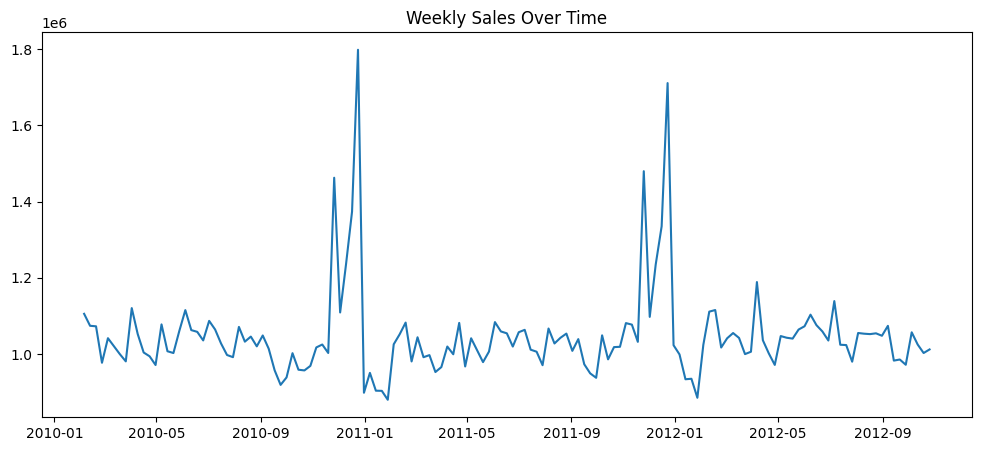

In [48]:
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values)
plt.title("Weekly Sales Over Time")
plt.show()

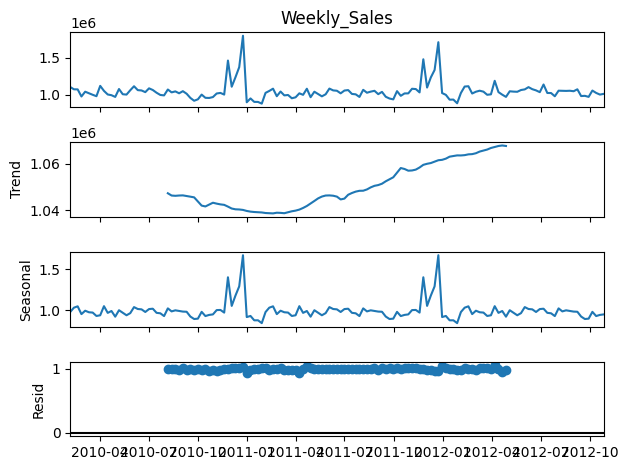

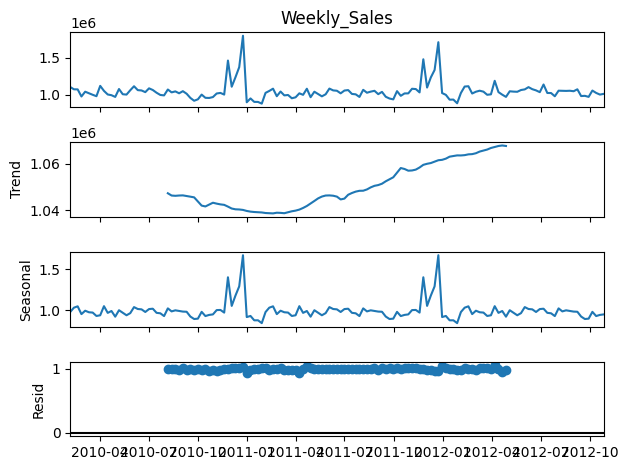

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = df.groupby('Date')['Weekly_Sales'].mean()

result = seasonal_decompose(ts, model='multiplicative', period=52)
result.plot()

Yes there is Seasonality in the data and we can observe that there in a rise in the sales from the December to January because we have Christmas festival, New Year which promote gift pruchasing and overall shopping rate.

In [52]:
df[['Temperature', 'Weekly_Sales']].corr()

,Temperature,Weekly_Sales
Temperature,1.00000,-0.06381
Weekly_Sales,-0.06381,1.00000


Temperature doesnot affect the weekly sales because the correlation value - (-0.06381) is close to 0.

In [54]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [55]:
df[['CPI', 'Weekly_Sales']].corr()

,CPI,Weekly_Sales
CPI,1.000000,-0.072634
Weekly_Sales,-0.072634,1.000000


In [56]:
cpi_correlation = df.groupby('Store').apply(lambda x:x['CPI'].corr(x['Weekly_Sales']))
print(cpi_correlation)

Store
1     0.225408
2    -0.062431
3     0.317250
4     0.351157
5     0.308261
6    -0.011357
7     0.289044
8     0.120255
9     0.294805
10   -0.115374
11    0.069781
12    0.084087
13    0.163976
14   -0.419755
15   -0.174467
16    0.124285
17    0.348571
18   -0.193541
19   -0.155341
20    0.058706
21   -0.163649
22   -0.038602
23    0.084248
24   -0.013684
25   -0.010914
26    0.131980
27   -0.213082
28   -0.095908
29   -0.072530
30   -0.298188
31    0.132887
32    0.196782
33   -0.052271
34    0.115437
35   -0.424107
36   -0.915095
37    0.244507
38    0.812837
39    0.428043
40    0.113318
41    0.392293
42    0.360859
43   -0.285686
44    0.740150
45   -0.023548
dtype: float64


Customer Price Index is correlated with the Weekly Sales of the stores both negatively and positively.

In [57]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

In [63]:
top_stores = store_sales.sort_values(ascending=False)
print("Top 10 performing stores are: ")
for i in range(0,10):
  print(f"{top_stores.index[i]}", end=',')

Top 10 performing stores are: 
20,4,14,13,2,10,27,6,1,39,

In [65]:
best_store = store_sales.idxmax()
worst_store = store_sales.idxmin()

best_value = store_sales.max()
worst_value = store_sales.min()

print(f"Best Store: {best_store}, Best Sales: {best_value}")
print(f"Worst Store: {worst_store}, Worst Sales: {worst_value}")

Best Store: 20, Best Sales: 301397792.46
Worst Store: 33, Worst Sales: 37160221.96


In [66]:
difference = best_value - worst_value
print(f"Difference between sales: {difference}")

Difference between sales: 264237570.49999997


In [70]:
percentage_diff = (difference / best_value) * 100
print(f"Worst store is {percentage_diff:.2f}% lower than best")

percentage_diff2 = (difference / worst_value) * 100
print(f"Best store is {percentage_diff2:.2f}% lower than worst")

Worst store is 87.67% lower than best
Best store is 711.08% lower than worst


There is a very much significant difference between the weekly sales of best and worst stores.

In [79]:
df_final = df_sorted.groupby('Date')['Weekly_Sales'].sum()
df_final.head()

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


In [81]:
df_final = df_final.sort_index()
df_final.head()

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


In [82]:
df_final.index = pd.to_datetime(df_final.index, format="%d-%m-%Y")

In [84]:
df_final = pd.DataFrame(data=df_final, index=df_final.index)
df_final.head()

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


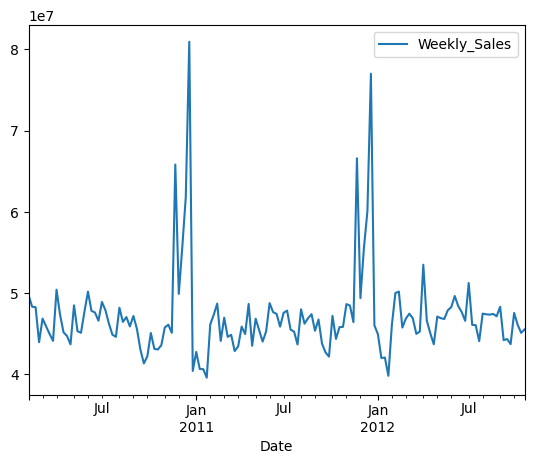

In [85]:
df_final.plot()
plt.show()

In [87]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_final['Weekly_Sales'])
print(f"p-value: {result[1]}")
if result[1] <= 0.05:
  print("The data is stationary")
else:
  print("The data is not stationary")

p-value: 2.675979158986003e-07
The data is stationary


In [89]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.3 MB/s eta 0:00:00


In [91]:
from pmdarima import auto_arima

In [92]:
auto = auto_arima(df_final['Weekly_Sales'])

In [93]:
auto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  143
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -2410.710
Date:                Mon, 13 Apr 2026   AIC                           4829.420
Time:                        15:33:31   BIC                           4841.271
Sample:                    02-05-2010   HQIC                          4834.235
                         - 10-26-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2.741e+07   9.41e-10   2.91e+16      0.000    2.74e+07    2.74e+07
ar.L1          0.2968      0.048      6.147      0.000       0.202       0.391
ar.L2          0.1214      0.052      2.323      0.020       0.019       0.224
sigma2      2.601e+13   9.32e-16   2.79e+28      0.000     2.6e+13     2.6e+13
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1162.94
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.62   Skew:                             2.56
Prob(H) (two-sided):                  0.11   Kurtosis:                        16.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.85e+43. Standard errors may be unstable.
"""

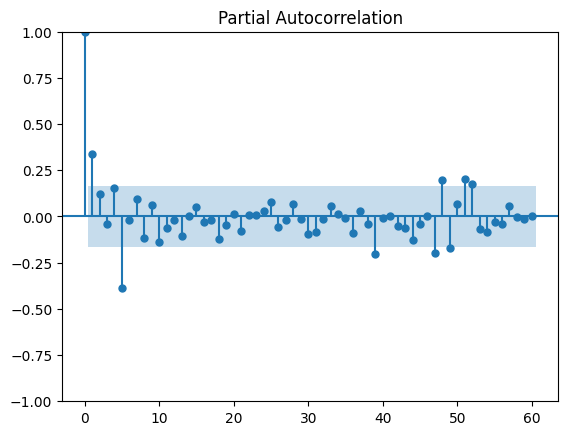

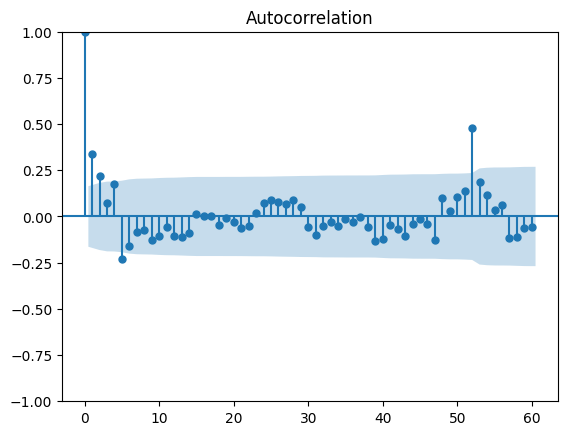

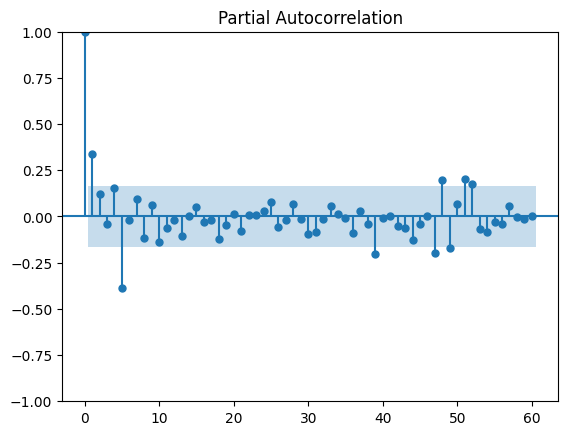

In [94]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_final['Weekly_Sales'], lags=60)
plot_pacf(df_final['Weekly_Sales'], lags=60)

In [108]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df_final['Weekly_Sales'], order=(2,0,0), seasonal_order=(2,1,3,52))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Forecast for the next 12 weeks

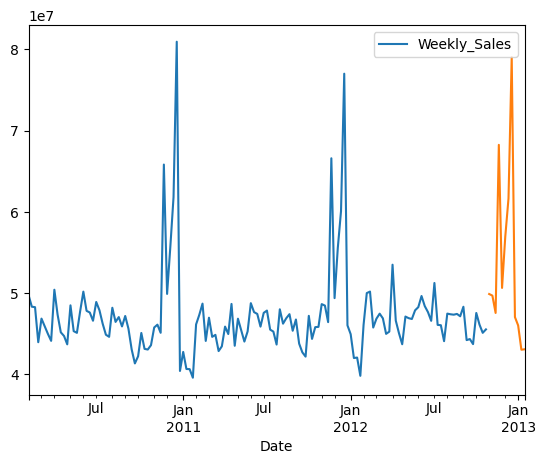

In [110]:
forecasted = model_fit.forecast(steps=12)
df_final.plot()
forecasted.plot()
plt.show()